# 02 · Transición estocástica (resbalón)

**Curso MIA-204 · Trabajo final · Deep RL**

Subimos la complejidad haciendo el mundo **estocástico**: con probabilidad proporcional
a la pendiente, el paso *resbala* y sale hacia un lado al azar (`prob_resbalon`). El
agente decide firme, pero el terreno puede desviarlo — como caminar sobre piedra suelta.

Es donde el RL model-free tiene sentido: no hay modelo del mundo, el agente debe aprender
una política **robusta al azar**. Comparamos DQN en terreno determinista vs estocástico.
Mismo entorno y agente que el notebook 01 (código común).

In [10]:
# ── Setup: montar Google Drive e importar el código común ──
# Sube la carpeta proyecto-rl/ a tu Drive. Ajusta RUTA si la pusiste en otro lado.
import sys
# Ruta del código común (carpeta dqn/ en tu Drive). Cámbiala si la mueves.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    RUTA = '/content/drive/Othercomputers/My Mac/dqn'
except ImportError:
    RUTA = '.'   # ejecución local desde la carpeta dqn/
sys.path.insert(0, RUTA)
print('RUTA del código común:', RUTA)

try:
    import rasterio
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', '-q', 'rasterio'])

import numpy as np, torch
import matplotlib.pyplot as plt
from entorno_drl import TerrenoDRLEnv, NUM_ACCIONES
from dqn import AgenteDQN
from train import entrenar, evaluar, pares_de_evaluacion, suavizar
from baselines import dijkstra, ruta_greedy, costo_camino, brecha_vs_dijkstra
from datos import ruta_dem
import viz

device = 'cuda' if torch.cuda.is_available() else 'cpu'
SEMILLA = 42
np.random.seed(SEMILLA); torch.manual_seed(SEMILLA)
RUTA_DEM = ruta_dem(RUTA)
print('dispositivo:', device, '| DEM:', RUTA_DEM)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RUTA del código común: /content/drive/Othercomputers/My Mac/dqn
dispositivo: cuda | DEM: /content/drive/Othercomputers/My Mac/dqn/dem.tif


## 0 · El terreno (mismo mapa real que el notebook 01)

Recordatorio del entorno: elevación y pendiente del recorte del Misti, y lo que ve
el agente (parche local 9×9 + vector a la meta). El código del entorno es común.

Mapa 108x108 | meta fija en (np.int64(104), np.int64(104)) | obs = 83 números


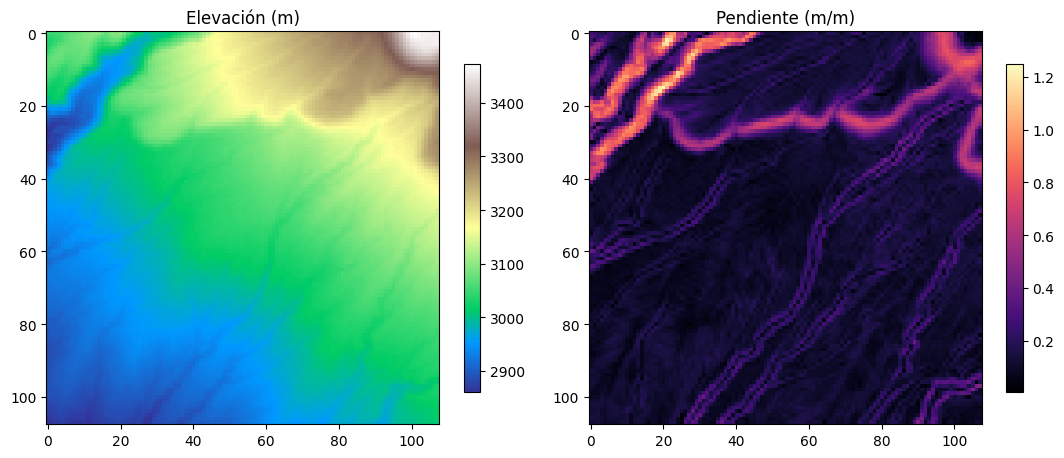

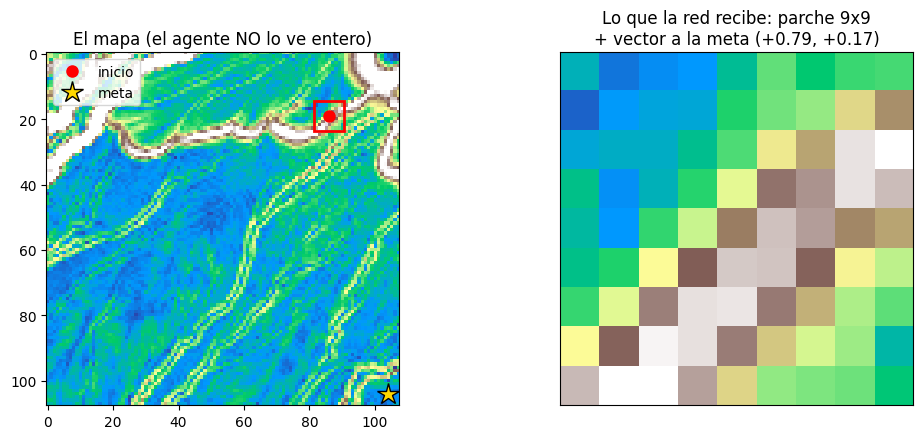

In [11]:
env = TerrenoDRLEnv(RUTA_DEM, semilla=SEMILLA)
print(f'Mapa {env.filas}x{env.columnas} | meta fija en {env.meta_fija} | obs = {env.dim_obs} números')
viz.mapa_terreno(env); plt.show()
viz.que_ve_el_agente(env); plt.show()

## 1 · Entrenar: determinista vs estocástico

`prob_resbalon=0.0` (determinista) contra `prob_resbalon=0.25` (en pendiente máxima,
25% de resbalar). Misma semilla y episodios para comparar limpio.

In [ ]:
EPISODIOS_EXP = 1500     # converge ~1400; sube a 3000 para el informe

def entrenar_resbalon(prob):
    e = TerrenoDRLEnv(RUTA_DEM, prob_resbalon=prob, semilla=SEMILLA)
    a = AgenteDQN(e.dim_obs, NUM_ACCIONES, device=device, semilla=SEMILLA)
    h = entrenar(e, a, EPISODIOS_EXP, eval_cada=100, verbose=True)
    return e, a, h

print('Entrenando DETERMINISTA (resbalón = 0.0) ...')
env_det, ag_det, h_det = entrenar_resbalon(0.0)
print('Entrenando ESTOCÁSTICO (resbalón = 0.25) ...')
env_sto, ag_sto, h_sto = entrenar_resbalon(0.25)

Entrenando DETERMINISTA (resbalón = 0.0) ...
Entrenando ESTOCÁSTICO (resbalón = 0.25) ...


## 2 · Comparación

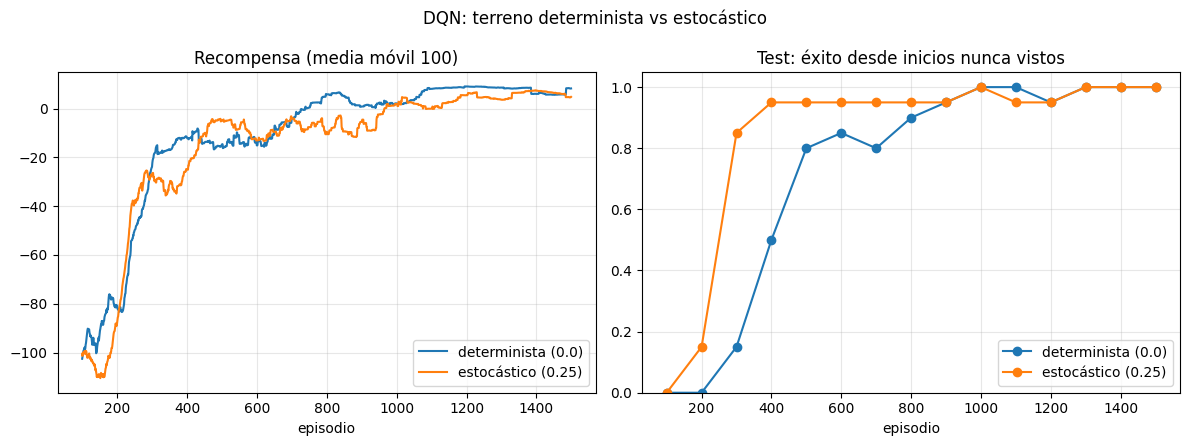

Final determinista: 100% éxito, 96 pasos
Final estocástico:  100% éxito, 102 pasos


In [8]:
viz.comparar_curvas([h_det, h_sto],
    ['determinista (0.0)', 'estocástico (0.25)'],
    'DQN: terreno determinista vs estocástico'); plt.show()
print(f'Final determinista: {h_det["eval_exito"][-1]:.0%} éxito, {h_det["eval_pasos"][-1]:.0f} pasos')
print(f'Final estocástico:  {h_sto["eval_exito"][-1]:.0%} éxito, {h_sto["eval_pasos"][-1]:.0f} pasos')

## 3 · Rutas bajo azar

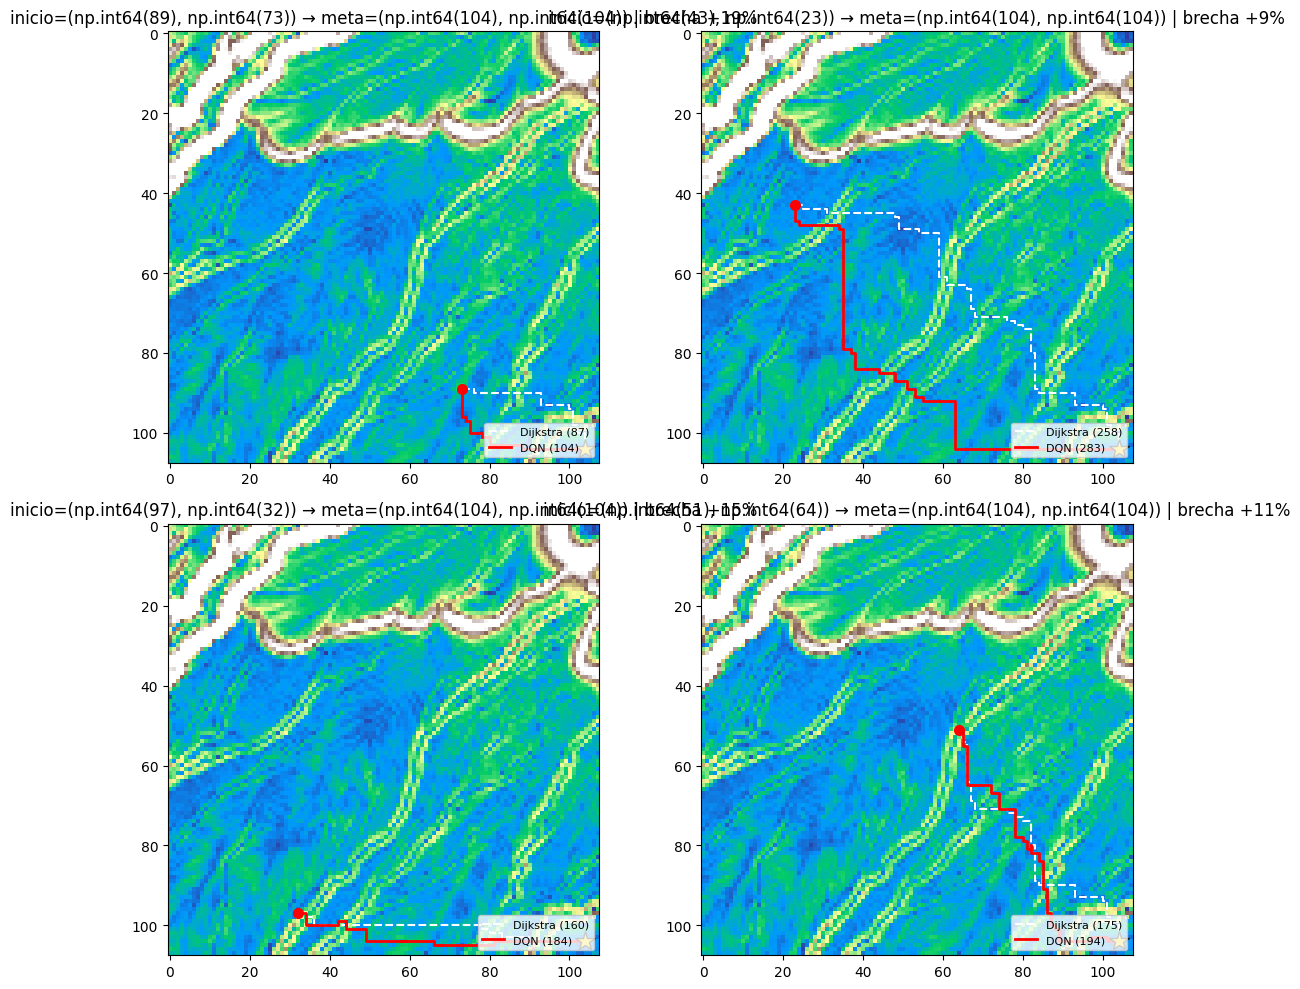

In [9]:
pares = pares_de_evaluacion(env_sto)
viz.rutas_vs_dijkstra(env_sto, ag_sto, pares, n=4); plt.show()

## 4 · Qué muestra (para el informe)

El estocástico llega a algo menos de 100 % y en más pasos: **el azar cuesta**. Pero el
agente aún aprende una política que llega desde inicios no vistos pese al resbalón, y
aprende a **evitar las pendientes con más cuidado** (ahí resbala). Esto justifica RL:
Dijkstra calcula la ruta óptima asumiendo mundo determinista; en un mundo con azar esa
ruta puede ser mala, y una política aprendida es más robusta.